# Cost Prediction: Data Preparation
This notebook prepares the dataset to predict cost given knob configuration and workload internal metrics.

- Source records: `surrogate/combined_runhistory.json` (`records` contain knob config and `cost`).
- Internal metrics: `internal_metrics/<bench>/<bench>_<idx>_internal_metrics.json` selected by parsing `__source` in each record.
- Output: `x_train, y_train, x_test, y_test` ready for model training.

In [84]:
import os
import re
import json
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

cwd = Path.cwd()
surrogate_dir_candidates = [cwd, cwd / 'surrogate']
combo_path = None
for cand in surrogate_dir_candidates:
    cp = cand / 'combined_runhistory.json'
    if cp.exists():
        combo_path = cp
        break
if combo_path is None:
    combo_path = Path('/Users/nisith/Desktop/FYP/E2ETune-AI4DB/surrogate/combined_runhistory.json')

project_root = combo_path.parent.parent if combo_path.name == 'combined_runhistory.json' else cwd
internal_metrics_dir = project_root / 'internal_metrics'
print('Using combined_runhistory.json at:', combo_path)
print('Using internal metrics dir:', internal_metrics_dir)

Using combined_runhistory.json at: /Users/nisith/Desktop/FYP/E2ETune-AI4DB/surrogate/combined_runhistory.json
Using internal metrics dir: /Users/nisith/Desktop/FYP/E2ETune-AI4DB/internal_metrics


In [85]:
bench_patterns = {
    'job': re.compile(r"job_(\d+)_hebo_output"),
    'tpch': re.compile(r"tpch_(\d+)_hebo_output"),
    'tpcds': re.compile(r"tpcds_(\d+)_hebo_output"),
    'ssb': re.compile(r"ssb_(\d+)_hebo_output"),
    'tpcc': re.compile(r"sample_tpcc_config(\d+)_hebo_output"),
    'smallbank': re.compile(r"sample_smallbank_config(\d+)_hebo_output"),
    'twitter': re.compile(r"sample_twitter_config(\d+)_hebo_output"),
}

def parse_bench_and_idx(source_path: str):
    p = Path(source_path)
    parts = [str(x) for x in p.parts]
    bench = None
    for b in ['job','tpch','tpcds','ssb','tpcc','smallbank','twitter']:
        if b in parts:
            bench = b
            break
    if bench is None:
        return None

    match = bench_patterns[bench].search(source_path)
    if not match:
        return None
    idx = int(match.group(1))
    return bench, idx

def metrics_path_for(bench: str, idx: int) -> Path:
    # Standard path format
    standard_path = internal_metrics_dir / bench / f"{bench}_{idx}_internal_metrics.json"
    if standard_path.exists():
        return standard_path
    
    # Alternative path formats for different benchmarks
    if bench == 'tpcc':
        alt_path = internal_metrics_dir / bench / f"sample_tpcc_config{idx}.xml_internal_metrics.json"
        if alt_path.exists():
            return alt_path
    elif bench == 'smallbank':
        alt_path = internal_metrics_dir / bench / f"sample_smallbank_config{idx}.xml_internal_metrics.json"
        if alt_path.exists():
            return alt_path
    elif bench == 'twitter':
        alt_path = internal_metrics_dir / bench / f"sample_twitter_config{idx}.xml_internal_metrics.json"
        if alt_path.exists():
            return alt_path
    
    return standard_path

_metrics_cache = {}

def load_internal_metrics(bench: str, idx: int) -> dict:
    key = (bench, idx)
    if key in _metrics_cache:
        return _metrics_cache[key]
    mp = metrics_path_for(bench, idx)
    if not mp.exists():
        return {}
    try:
        with open(mp, 'r') as f:
            raw = json.load(f)
        flat = pd.json_normalize(raw, sep='__')
        metrics = flat.to_dict(orient='records')[0] if len(flat) else {}
    except Exception:
        metrics = {}
    _metrics_cache[key] = metrics
    return metrics


In [86]:
def select_config_dict(rec: dict):
    if 'config' in rec and isinstance(rec['config'], dict):
        return rec['config']
    else:
        return None

def select_cost_value(rec: dict):
    if 'cost' in rec:
        v = rec.get('cost')
        if isinstance(v, (int, float)) or (isinstance(v, list) and len(v) == 1 and isinstance(v[0], (int, float))):
            cost = float(v[0]) if isinstance(v, list) else float(v)
            return abs(cost)  # Make all costs positive
    else:
        return None

with open(combo_path, 'r') as f:
    combo = json.load(f)
records = combo.get('records', [])
print('Loaded records:', len(records))

feature_rows = []
targets = []

skipped_no_cost = 0
skipped_no_config = 0
skipped_no_metrics = 0

for rec in records:
    src = rec.get('__source', '')
    parsed = parse_bench_and_idx(src)
    if not parsed:
        skipped_no_metrics += 1
        continue
    bench, idx = parsed
    metrics = load_internal_metrics(bench, idx)
    config = select_config_dict(rec)
    cost = select_cost_value(rec)

    if cost is None:
        skipped_no_cost += 1
        continue
    if config is None:
        skipped_no_config += 1
        continue

    config_flat = pd.json_normalize(config, sep='__').to_dict(orient='records')[0] if isinstance(config, dict) else {}
    row = {}
    row.update({f'cfg__{k}': v for k, v in config_flat.items()})
    row.update({f'metrics__{k}': v for k, v in metrics.items()})
    row['bench'] = bench
    row['workload_idx'] = idx

    feature_rows.append(row)
    targets.append(cost)

print('Rows collected:', len(feature_rows))
print('Skipped (no cost):', skipped_no_cost)
print('Skipped (no config):', skipped_no_config)
print('Skipped (no metrics parse):', skipped_no_metrics)

df = pd.DataFrame(feature_rows)
print('Raw feature shape:', df.shape)
df.head(3)

Loaded records: 9191
Rows collected: 9191
Skipped (no cost): 0
Skipped (no config): 0
Skipped (no metrics parse): 0
Raw feature shape: (9191, 31)


,cfg__shared_buffers,cfg__work_mem,cfg__maintenance_work_mem,cfg__effective_cache_size,cfg__max_connections,cfg__wal_buffers,cfg__checkpoint_completion_target,cfg__checkpoint_timeout,cfg__effective_io_concurrency,cfg__join_collapse_limit,...,metrics__tup_inserted,metrics__conflicts,metrics__tup_updated,metrics__tup_deleted,metrics__disk_read_count,metrics__disk_write_count,metrics__disk_read_bytes,metrics__disk_write_bytes,bench,workload_idx
0,131072.0,65536.0,262144.0,3145728.0,200.0,2048.0,0.900000,900.0,100.0,8.0,...,0.0,0.0,0.0,0.0,951242.0,0.0,7.792574e+09,0.0,job,0
1,568513.0,55023.0,1205460.0,363298.0,116.0,529.0,0.830175,1346.0,50.0,17.0,...,0.0,0.0,0.0,0.0,951242.0,0.0,7.792574e+09,0.0,job,0
2,1393434.0,227880.0,930768.0,2785250.0,455.0,5912.0,0.624197,525.0,235.0,9.0,...,0.0,0.0,0.0,0.0,951242.0,0.0,7.792574e+09,0.0,job,0


In [87]:
import pandas as pd
import numpy as np

# Calculate average cost per benchmark

# Create a DataFrame with cost and benchmark info
cost_by_bench = pd.DataFrame({
    'cost': targets,
    'benchmark': [row['bench'] for row in feature_rows]
})

# Calculate average cost per benchmark
avg_cost_per_bench = cost_by_bench.groupby('benchmark')['cost'].agg(['count', 'mean', 'std', 'min', 'max']).round(4)
avg_cost_per_bench.columns = ['count', 'avg_cost', 'std_cost', 'min_cost', 'max_cost']

print("Average cost per benchmark:")
print("=" * 50)
print(avg_cost_per_bench.sort_values('avg_cost', ascending=False))

# Overall statistics
print(f"\nOverall statistics:")
print(f"Total records: {len(targets)}")
print(f"Overall average cost: {np.mean(targets):.4f}")
print(f"Overall std cost: {np.std(targets):.4f}")

Average cost per benchmark:
           count   avg_cost   std_cost   min_cost    max_cost
benchmark                                                    
twitter     1313  8131.1517  2255.5919  2884.3710  12220.3042
tpcc        1313  2283.0231  1370.7908   892.7487   7236.5413
smallbank   1313  1458.6302   264.7281   944.0953   2167.3335
job         1313    10.8674    28.4389     0.1276    135.3516
tpcds       1313     6.7347     4.5423     1.1575     24.8840
ssb         1313     2.6709     1.1127     0.5082      4.9899
tpch        1313     1.9487     1.0542     0.2936      4.4909

Overall statistics:
Total records: 9191
Overall average cost: 1699.2895
Overall std cost: 2934.3975


In [88]:
# # Per-workload target normalization
# normalization = 'minmax'  # options: 'zscore', 'minmax'

# # Build group key (bench + workload_idx)
grp = df['bench'].astype(str) + '_' + df['workload_idx'].astype(str)
# cost_series = pd.Series(targets, name='cost')
# cost_series_log = np.log1p(pd.Series(targets, name='cost'))
# def _zscore(vals: pd.Series):
#     s = float(vals.std(ddof=0))
#     if s == 0 or np.isnan(s):
#         return vals * 0.0
#     m = float(vals.mean())
#     return (vals - m) / s

# def _minmax(vals: pd.Series):
#     mn = float(vals.min()); mx = float(vals.max())
#     if mx == mn:
#         return vals * 0.0
#     return (vals - mn) / (mx - mn)

# if normalization == 'zscore':
#     norm_series = cost_series.groupby(grp).transform(_zscore)
# else:
#     norm_series = cost_series.groupby(grp).transform(_minmax)

# y_norm = norm_series.values.astype(float)
# print(f"Per-workload normalization: {normalization}")
# print('y_norm stats -> mean:', float(np.nanmean(y_norm)), 'std:', float(np.nanstd(y_norm)))


cost_series_log = np.log1p(pd.Series(targets, name='cost'))

# Now apply MinMax on the LOG values
def _minmax(vals: pd.Series):
    mn = float(vals.min())
    mx = float(vals.max())
    if mx == mn:
        return vals * 0.0
    return (vals - mn) / (mx - mn)

# Use the log series for grouping and transformation
norm_series = cost_series_log.groupby(grp).transform(_minmax)

y_norm = norm_series.values.astype(float)
print(f"Applied Log1p -> MinMax Normalization")

Applied Log1p -> MinMax Normalization


In [89]:
# Format features: one-hot categorical,split train/test
# Identify feature columns and target
y_raw = np.array(targets)
try:
    y = y_norm
except NameError:
    y = y_raw

X = df.copy()

# Drop grouping-only columns to prevent leakage
for col in ['bench', 'workload_idx']:
    if col in X.columns:
        X = X.drop(columns=[col])

# Normalize knob columns using ranges from knob_config/knob_config.json
import json

# Load knob ranges (use project_root if available)
try:
    with open(project_root / 'knob_config/knob_config.json', 'r') as f:
        knob_ranges = json.load(f)
except Exception:
    with open('knob_config/knob_config.json', 'r') as f:
        knob_ranges = json.load(f)

def _normalize_knob(orig_key, val):
    rng = knob_ranges.get(orig_key)
    if rng is None:
        # If knob not in ranges, pass through numeric value
        return float(val) if pd.notnull(val) else 0.0
    mn = float(rng.get('min', 0.0))
    mx = float(rng.get('max', mn))
    if not pd.notnull(val):
        return 0.0
    v = float(val)
    return 0.0 if mx == mn else (v - mn) / (mx - mn)

# Apply normalization to all cfg__* columns
cfg_cols = [c for c in X.columns if c.startswith('cfg__')]
for c in cfg_cols:
    orig = c.replace('cfg__', '')
    X[c] = pd.to_numeric(X[c], errors='coerce')
    X[c] = X[c].apply(lambda v: _normalize_knob(orig, v))

# Convert categorical columns (object dtype) to dummies
categorical_cols = [c for c in X.columns if X[c].dtype == 'object']
X = pd.get_dummies(X, columns=categorical_cols, dummy_na=True)

# Optional: ensure numeric type
for col in X.columns:
    # Convert booleans to ints
    if X[col].dtype == bool:
        X[col] = X[col].astype(int)
    # Convert any non-numeric to string dummies already; remaining should be numeric
    if not np.issubdtype(X[col].dtype, np.number):
        try:
            X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)
        except Exception:
            pass

print('Final feature shape:', X.shape)



Final feature shape: (9191, 29)


In [90]:
# Group-aware train/test split (hold out entire workloads)
from sklearn.model_selection import GroupShuffleSplit
groups = df['bench'].astype(str) + '_' + df['workload_idx'].astype(str)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

# from sklearn.model_selection import train_test_split
# train_idx, test_idx = train_test_split(np.arange(len(X)), test_size=0.2, random_state=42)

# Train-only min–max normalization for workload metrics (metrics__*)
metrics_cols = [c for c in X.columns if c.startswith('metrics__')]
if len(metrics_cols) > 0:
    # Ensure numeric
    for c in metrics_cols:
        X[c] = pd.to_numeric(X[c], errors='coerce')
    train_metrics = X.iloc[train_idx][metrics_cols]
    mn = train_metrics.min()
    mx = train_metrics.max()
    rng = mx - mn
    rng = rng.replace(0, np.nan)
    X.loc[:, metrics_cols] = (X[metrics_cols] - mn) / rng
    X.loc[:, metrics_cols] = X[metrics_cols].fillna(0.0).clip(0.0, 1.0)
    print('Applied train-only min–max normalization to metrics__* columns.')

x_train, x_test = X.values[train_idx], X.values[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print('Group-aware split:', x_train.shape, x_test.shape)

Applied train-only min–max normalization to metrics__* columns.
Group-aware split: (7272, 29) (1919, 29)


In [106]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

rf = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)

print("\nTraining RandomForest and GradientBoosting for comparison...")
rf.fit(x_train, y_train)
gb.fit(x_train, y_train)

rf_predictions = rf.predict(x_test)
gb_predictions = gb.predict(x_test)

rf_r2 = r2_score(y_test, rf_predictions)
gb_r2 = r2_score(y_test, gb_predictions)

print(f"\nModel Comparison:")
print(f"RandomForest R²: {rf_r2:.4f}")
print(f"GradientBoosting R²: {gb_r2:.4f}")


Training RandomForest and GradientBoosting for comparison...

Model Comparison:
RandomForest R²: 0.2940
GradientBoosting R²: 0.3210


In [107]:
from sklearn.ensemble import VotingRegressor

# Create a voting regressor that combines the best performing models
voting = VotingRegressor(estimators=[('gb', gb), ('rf', rf)])

print("Training Voting Regressor...")
voting.fit(x_train, y_train)

# Make predictions
voting_predictions = voting.predict(x_test)

# Calculate metrics
voting_r2 = r2_score(y_test, voting_predictions)
voting_mae = mean_absolute_error(y_test, voting_predictions)
try:
    voting_rmse = mean_squared_error(y_test, voting_predictions, squared=False)
except TypeError:
    voting_rmse = mean_squared_error(y_test, voting_predictions) ** 0.5

print(f"\nVoting Regressor Performance:")
print(f"R² Score: {voting_r2:.4f}")
print(f"Mean Absolute Error: {voting_mae:.4f}")
print(f"Root Mean Squared Error: {voting_rmse:.4f}")

Training Voting Regressor...

Voting Regressor Performance:
R² Score: 0.3324
Mean Absolute Error: 0.1783
Root Mean Squared Error: 0.2191


In [108]:
from scipy.stats import spearmanr

# 1. Calculate Spearman Rank Correlation
# This measures: "Did we correctly predict that Config A is better than Config B?"
# regardless of the absolute values.
train_spearman, _ = spearmanr(y_train, voting.predict(x_train))
test_spearman, _ = spearmanr(y_test, voting.predict(x_test))

print(f"Spearman Rank Correlation (Train): {train_spearman:.4f}")
print(f"Spearman Rank Correlation (Test):  {test_spearman:.4f}")

# Interpretation Guide
print("\n--- Interpretation ---")
print("If Test Spearman > 0.7:  EXCELLENT. The model is ready for the Tuner.")
print("If Test Spearman ~ 0.5:  GOOD. It will tune, but slowly.")
print("If Test Spearman < 0.3:  BAD. The model is guessing.")

Spearman Rank Correlation (Train): 0.9278
Spearman Rank Correlation (Test):  0.5627

--- Interpretation ---
If Test Spearman > 0.7:  EXCELLENT. The model is ready for the Tuner.
If Test Spearman ~ 0.5:  GOOD. It will tune, but slowly.
If Test Spearman < 0.3:  BAD. The model is guessing.


In [94]:
# Check which benchmarks ended up in Train vs Test
train_rows = df.iloc[train_idx]
test_rows = df.iloc[test_idx]

print(f"Training on: {train_rows['bench'].unique()}")
print(f"Testing on:  {test_rows['bench'].unique()}")

Training on: ['job' 'smallbank' 'ssb' 'tpcc' 'tpcds' 'tpch' 'twitter']
Testing on:  ['job' 'smallbank' 'ssb' 'tpcc' 'tpcds' 'tpch' 'twitter']


In [97]:
# Check intersection of specific workloads
train_workloads = set(train_rows['bench'].astype(str) + '_' + train_rows['workload_idx'].astype(str))
test_workloads = set(test_rows['bench'].astype(str) + '_' + test_rows['workload_idx'].astype(str))

overlap = train_workloads.intersection(test_workloads)

if len(overlap) > 0:
    print(f"⚠️ WARNING: {len(overlap)} workloads differ across Train and Test.")
    print(f"Examples of leaking workloads: {list(overlap)[:5]}")
else:
    print("✅ Success: No workload overlap. The model is being tested on unseen workloads.")

✅ Success: No workload overlap. The model is being tested on unseen workloads.


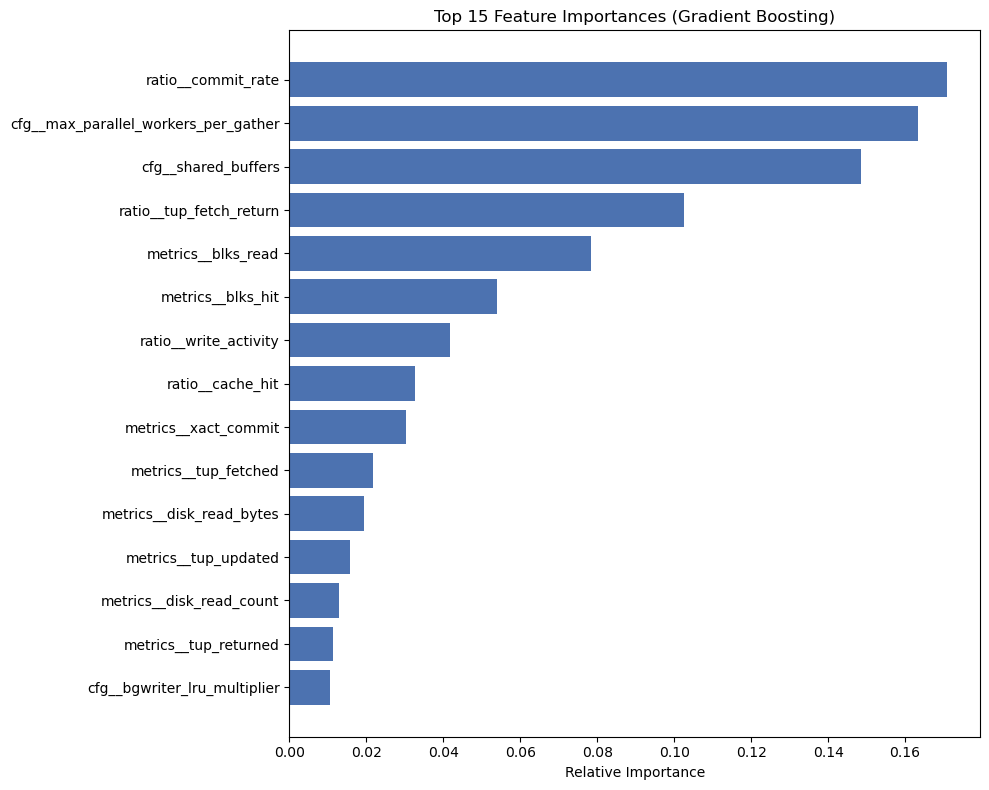

Top 5 Features:
ratio__commit_rate: 0.1709
cfg__max_parallel_workers_per_gather: 0.1634
cfg__shared_buffers: 0.1484
ratio__tup_fetch_return: 0.1026
metrics__blks_read: 0.0784


In [55]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Use the best model from your comparison (GradientBoosting)
model = gb  

# Get feature importance
importances = model.feature_importances_

# Get feature names (columns from your training matrix X)
# We need to ensure we map them correctly to the one-hot encoded columns
feature_names = X.columns

# Sort indices to get the top 15 most important features
indices = np.argsort(importances)[-15:]

plt.figure(figsize=(10, 8))
plt.title('Top 15 Feature Importances (Gradient Boosting)')
plt.barh(range(len(indices)), importances[indices], color='#4c72b0', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

# Quick text summary
print("Top 5 Features:")
for i in reversed(indices[-5:]):
    print(f"{feature_names[i]}: {importances[i]:.4f}")

In [103]:
# Evaluation-only: safe RMSE without re-running tuning
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr

def _rmse_safe(y_true, y_pred):
    try:
        return mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        return float(mean_squared_error(y_true, y_pred) ** 0.5)

def eval_model_safe(name, model):
    preds = model.predict(x_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = _rmse_safe(y_test, preds)
    corr = spearmanr(y_test, preds).correlation
    spearman = float(corr if np.isfinite(corr) else 0.0)
    print(f"\n{name} Test Performance:")
    print(f"R²: {r2:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | Spearman: {spearman:.4f}")

# Evaluate tuned models if present (no re-tuning)
try:
    eval_model_safe("RandomForest (tuned)", rf_best)
    eval_model_safe("GradientBoosting (tuned)", gb_best)
except NameError:
    pass

# Also evaluate models instantiated with specified params if present
try:
    eval_model_safe("RandomForest (specified params)", rf)
    eval_model_safe("GradientBoosting (specified params)", gb)
except NameError:
    print("Manual models rf/gb not found; please run the comparison cell.")

# Optional: equal-weight voting (no weight tuning)
try:
    from sklearn.ensemble import VotingRegressor
    voting_eq = VotingRegressor(estimators=[('gb', gb), ('rf', rf)])
    voting_eq.fit(x_train, y_train)
    eval_model_safe("VotingRegressor (equal weights, specified params)", voting_eq)
except Exception as ex:
    print("Voting evaluation skipped:", ex)


RandomForest (tuned) Test Performance:
R²: 0.2494 | MAE: 0.1953 | RMSE: 0.2323 | Spearman: 0.4947

GradientBoosting (tuned) Test Performance:
R²: 0.2193 | MAE: 0.1984 | RMSE: 0.2369 | Spearman: 0.5069

RandomForest (specified params) Test Performance:
R²: 0.2494 | MAE: 0.1953 | RMSE: 0.2323 | Spearman: 0.4947

GradientBoosting (specified params) Test Performance:
R²: 0.2193 | MAE: 0.1984 | RMSE: 0.2369 | Spearman: 0.5069

VotingRegressor (equal weights, specified params) Test Performance:
R²: 0.2457 | MAE: 0.1963 | RMSE: 0.2329 | Spearman: 0.5170
